# LSTM Financial Forecasting for Stock Price Prediction

This project uses a stacked Long Short-Term Memory (LSTM) neural network to forecast stock closing prices from historical OHLCV (open, high, low, close, volume) market data.

## Overview

Time series forecasting in financial markets is challenging because prices reflect temporal dependencies, trend changes, and short-term noise. This notebook demonstrates an end-to-end deep learning workflow for sequence modeling using historical equity data.

In this project, I:

- Download historical stock data with `yfinance`
- Normalize and window the time series into supervised learning examples
- Build and train a stacked LSTM model in Keras
- Evaluate forecasting performance on a hold-out test set
- Visualize predicted versus actual closing prices
- Discuss model limitations, practical use cases, and next steps

## Objective

The goal is to show how recurrent neural networks can be applied to financial time series data to learn short-term temporal patterns and generate next-step price forecasts. This project is intended as a portfolio demonstration of sequence modeling, deep learning workflow design, and practical forecasting analysis in Python.


In [7]:
# If running in Google Colab, install yfinance (run once)
!pip install -q yfinance

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
# Configuration (tunable)
TICKER = "AAPL"              # Stock symbol to forecast
START_DATE = "2019-01-01"
END_DATE = "2024-10-31"

# Download daily price data
data = yf.download(TICKER, start=START_DATE, end=END_DATE)

# For simplicity, focus on the 'Close' column but keep full OHLCV for features
print(data.head())
print("Data shape:", data.shape)

/tmp/ipykernel_309/984076956.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2019-01-02  37.503727  37.724590  36.627404  36.784146  148158800
2019-01-03  33.768074  34.606398  33.722951  34.193172  365248800
2019-01-04  35.209610  35.278483  34.150426  34.323790  234428400
2019-01-07  35.131237  35.344976  34.649142  35.314102  219111200
2019-01-08  35.800953  36.055064  35.271361  35.518344  164101200
Data shape: (1468, 5)


In [10]:
# Use all original columns as features
values = data.values

# Train/test split by time (no shuffling)
train_size = int(len(values) * 0.8)
train_data = values[:train_size]
test_data = values[train_size:]

# Scale features to [0, 1] using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# Window the time series into supervised learning pairs
def create_windowed_dataset(data_array, window_size, target_col_index):
    """Create (X, y) pairs from a multivariate time series.

    Parameters
    ----------
    data_array : np.ndarray
        Scaled time series of shape (num_timesteps, num_features).
    window_size : int
        Number of past days to include in each input sequence.
    target_col_index : int
        Index of the column to predict (e.g., Close price).

    Returns
    -------
    X : np.ndarray of shape (num_samples, window_size, num_features)
    y : np.ndarray of shape (num_samples, 1)
    """
    X, y = [], []
    for i in range(window_size, len(data_array)):
        X.append(data_array[i - window_size:i])
        y.append(data_array[i, target_col_index])
    return np.array(X), np.array(y).reshape(-1, 1)

WINDOW_SIZE = 60   # Tunable: number of historical days used as input
TARGET_COL_INDEX = list(data.columns).index(("Close", TICKER))

X_train, y_train = create_windowed_dataset(train_scaled, WINDOW_SIZE, TARGET_COL_INDEX)
X_test, y_test = create_windowed_dataset(test_scaled, WINDOW_SIZE, TARGET_COL_INDEX)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1114, 60, 5)
y_train shape: (1114, 1)
X_test shape: (234, 60, 5)
y_test shape: (234, 1)


In [11]:
# Build a stacked LSTM model

NUM_UNITS_1 = 100   # Tunable: number of units in first LSTM layer
NUM_UNITS_2 = 50    # Tunable: number of units in second LSTM layer
DROPOUT_RATE = 0.2  # Tunable: regularization strength

model = Sequential()
model.add(
    LSTM(
        units=NUM_UNITS_1,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2]),
    )
)
model.add(Dropout(DROPOUT_RATE))
model.add(LSTM(units=NUM_UNITS_2, return_sequences=False))
model.add(Dropout(DROPOUT_RATE))
model.add(Dense(1))  # Predict next-day closing price

model.compile(optimizer="adam", loss="mse")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        42,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,651 (283.79 KB)

 Trainable params: 72,651 (283.79 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train the model with early stopping
EPOCHS = 30       # Tunable: number of training epochs
BATCH_SIZE = 32   # Tunable: batch size

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 202ms/step - loss: 0.0421 - val_loss: 0.0355
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0053 - val_loss: 0.0077
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0039 - val_loss: 0.0140
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0040 - val_loss: 0.0043
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0038 - val_loss: 0.0074
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0032 - val_loss: 0.0064
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0036 - val_loss: 0.0067
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0031 - val_loss: 0.0028
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0031 - val_loss: 0.0051
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0031 - val_loss: 0.0079
Epoch 12/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0

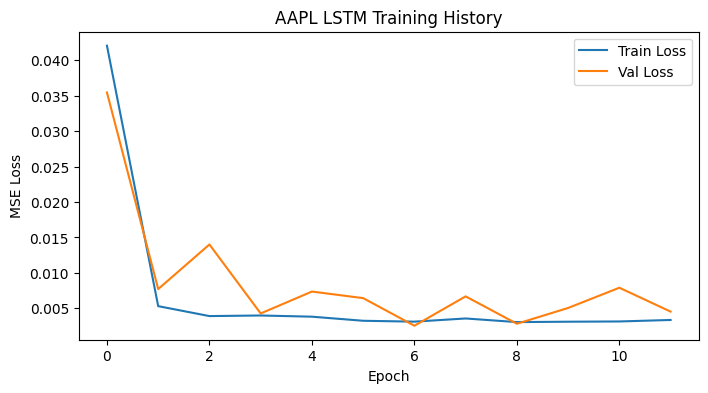

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
Test RMSE: 8.081250689981212


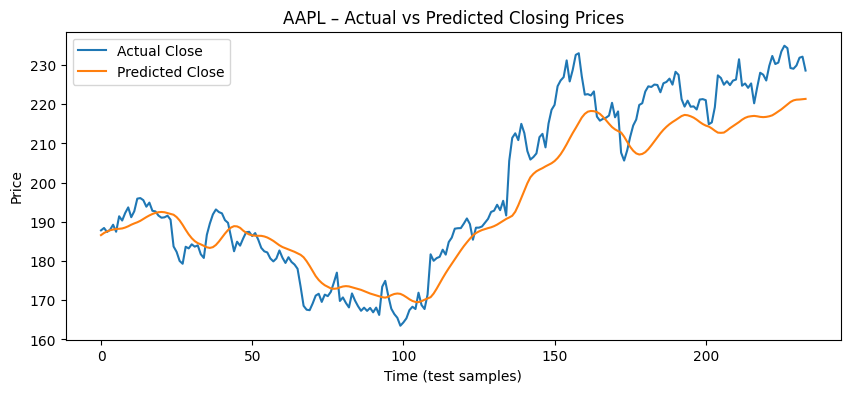

In [13]:
# Plot training and validation loss over epochs
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title(f"{TICKER} LSTM Training History")
plt.show()

# Make predictions on the test set
y_pred_scaled = model.predict(X_test)

# Inverse-transform the predictions and true values
# Build arrays that match the scaler's expected shape
num_features = train_scaled.shape[1]

test_pred_full = np.zeros((len(y_pred_scaled), num_features))
test_true_full = np.zeros((len(y_test), num_features))

test_pred_full[:, TARGET_COL_INDEX] = y_pred_scaled[:, 0]
test_true_full[:, TARGET_COL_INDEX] = y_test[:, 0]

y_pred = scaler.inverse_transform(test_pred_full)[:, TARGET_COL_INDEX]
y_true = scaler.inverse_transform(test_true_full)[:, TARGET_COL_INDEX]

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("Test RMSE:", rmse)

# Plot actual vs predicted prices
plt.figure(figsize=(10, 4))
plt.plot(y_true, label="Actual Close")
plt.plot(y_pred, label="Predicted Close")
plt.xlabel("Time (test samples)")
plt.ylabel("Price")
plt.title(f"{TICKER} – Actual vs Predicted Closing Prices")
plt.legend()
plt.show()

## Project Summary

This project implements a multivariate LSTM model to forecast daily closing prices for Apple (AAPL) using historical OHLCV data downloaded with `yfinance`. The workflow follows a standard deep learning time-series pipeline: data collection, feature scaling, sequence windowing, model training, hold-out evaluation, and visualization of predicted versus actual prices.

The modeling approach uses a 60-day rolling input window and a stacked LSTM architecture with dropout regularization to reduce overfitting. The network is trained with the Adam optimizer and mean squared error loss, with early stopping to improve generalization. After prediction, the results are inverse-transformed back into the original price scale and evaluated with RMSE to assess forecast quality on unseen data.

From a portfolio standpoint, this project demonstrates several practical skills: transforming raw sequential data into supervised learning format, building recurrent neural network architectures in Keras, evaluating time-dependent models appropriately, and interpreting performance in a business-facing context. While stock prediction is inherently noisy and limited by market volatility, this notebook provides a strong proof of concept for applying LSTM-based forecasting to financial and other sequential business problems such as sales demand, inventory planning, or operational trend prediction.

## Next Steps

Potential enhancements include:

- testing additional technical indicators as input features
- comparing LSTM results to baseline statistical models
- forecasting multiple steps ahead instead of one step
- tuning hyperparameters more systematically
- applying the same framework to other business time-series problems
